In [1]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
import torchvision.models as models
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt

## Dataset Class

In [2]:
class SatelliteDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_list, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = file_list # Only load the explicitly assigned split subset

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 1. Load Image
        img_path = os.path.join(self.image_dir, self.images[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 2. Load Mask (Uses the exact same filename as the image)
        mask_path = os.path.join(self.mask_dir, self.images[idx])
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Safety Check
        if mask is None:
            raise FileNotFoundError(f"Could not find or read mask file: {mask_path}. "
                                    f"Double check your mask directory layout!")

        # Standardize mask to 0 and 1
        mask = np.where(mask > 0, 1.0, 0.0).astype(np.float32)

        # 3. Apply Augmentations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.unsqueeze(0)


## Augmentation

In [3]:
train_transform_safe = A.Compose([
    A.RandomCrop(width=512, height=512), # Grabs a random 512x512 patch every epoch
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.CenterCrop(width=512, height=512), # Fixed, stable 512x512 region for evaluation
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

## Data Loaders

In [4]:
IMAGE_PATH = '/kaggle/input/datasets/qianlanzz/xbd-dataset/xbd/tier3/images'
MASK_PATH = '/kaggle/input/datasets/qianlanzz/xbd-dataset/xbd/tier3/masks'

all_pre_images = [f for f in os.listdir(IMAGE_PATH) if 'pre_disaster' in f]
all_pre_images.sort() # Sorting ensures identical indexing sequence splits

# divide data: 70% Train, 15% Val, 15% Test
# First Split: Separate 15% out for final testing
train_val_files, test_files = train_test_split(
    all_pre_images, 
    test_size=0.15, 
    random_state=42 # Fixed seed guarantees reproducibility across sessions
)

# Second Split: Separate 15% out of the remainder for validation (0.15 / 0.85 ≈ 0.176)
train_files, val_files = train_test_split(
    train_val_files, 
    test_size=0.176, 
    random_state=42
)

print(f"Dataset Splits -> Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Dataset Splits -> Train: 4460 | Val: 953 | Test: 956


## Core Global-Local Attention Block

In [5]:
class EfficientGlobalLocalAttention(nn.Module):
    def __init__(self, channels):
        super(EfficientGlobalLocalAttention, self).__init__()
        self.channels = channels
        
        # Local Attention Branch (Uses Depthwise Separable Convolution)
        self.local_branch = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, groups=channels, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True)
        )
        
        # Global Attention Branch (Reduces spatial dimension to map long-range features safely)
        self.pool = nn.AdaptiveAvgPool2d(4)  # Reduces feature map to a manageable 4x4 matrix
        self.fc_query = nn.Conv2d(channels, channels, kernel_size=1)
        self.fc_key   = nn.Conv2d(channels, channels, kernel_size=1)
        self.fc_value = nn.Conv2d(channels, channels, kernel_size=1)
        
        # Softmax to calculate raw attention probabilities
        self.softmax = nn.Softmax(dim=-1)
        
        # Final aggregation layer combining both branches
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        
        # 1. Process Local Branch
        local_feat = self.local_branch(x)
        
        # 2. Process Global Branch using spatial-reduction attention
        # We squash spatial dims into vectors to calculate Matrix Cross-Attention
        q = self.fc_query(x).flatten(2) # Shape: (B, C, H*W)
        
        pooled_x = self.pool(x)
        k = self.fc_key(pooled_x).flatten(2)   # Shape: (B, C, 16)
        v = self.fc_value(pooled_x).flatten(2) # Shape: (B, C, 16)
        
        # Transpose matrices to compute dot-product attention maps
        energy = torch.bmm(q.transpose(1, 2), k) # Intersecting wide queries with compact keys
        attention = self.softmax(energy)
        
        # Apply attention map weights to the global values
        global_feat = torch.bmm(v, attention.transpose(1, 2))
        global_feat = global_feat.view(B, C, H, W)
        
        # 3. Fuse the Context Layers together via element-wise addition
        fused = local_feat + global_feat
        return self.proj(fused)

## Transformer Decoder Block

In [6]:
class UNetFormerDecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super(UNetFormerDecoderBlock, self).__init__()
        
        # Attention block processing the feature input
        self.attention = EfficientGlobalLocalAttention(in_channels)
        
        # Upsampling module to double the spatial resolution (Height & Width)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        # Convolution blocks to seamlessly blend upsampled features with the skip features
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip_features):
        # Pass features through global-local attention
        x = self.attention(x)
        # Upsample spatial frame 
        x = self.upsample(x)
        # Concatenate with corresponding fine-grained layers from the encoder
        x = torch.cat([x, skip_features], dim=1)
        return self.conv(x)

## Stitching it Together (The Assembly Network)
Take a standard pre-trained ResNet-34 encoder and unite it with the Transformer decoder

In [7]:
class UNetFormer(nn.Module):
    def __init__(self, num_classes=1):
        super(UNetFormer, self).__init__()
        
        # 1. Initialize the CNN feature extraction engine
        # We use ResNet-34 pre-trained on ImageNet for rapid convergence on Kaggle
        resnet = models.resnet34(pretrained=True)
        
        # Break down ResNet blocks to capture hierarchical skip pathways
        self.encoder_initial = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool) 
        self.layer1 = resnet.layer1  # Out channels: 64
        self.layer2 = resnet.layer2  # Out channels: 128
        self.layer3 = resnet.layer3  # Out channels: 256
        self.layer4 = resnet.layer4  # Out channels: 512 (Deepest Bottleneck)
        
        # 2. Initialize the Transformer Decoders
        self.decoder3 = UNetFormerDecoderBlock(in_channels=512, skip_channels=256, out_channels=256)
        self.decoder2 = UNetFormerDecoderBlock(in_channels=256, skip_channels=128, out_channels=128)
        self.decoder1 = UNetFormerDecoderBlock(in_channels=128, skip_channels=64,  out_channels=64)
        
        # 3. Final Projection Head
        # Restores back to the true input resolution and maps down to a single binary channel
        self.final_upsample = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)
        self.final_conv = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, kernel_size=1) # Class output (Logits if num_classes=1)
        )

    def forward(self, x):
        # --- Contracting Path (CNN Encoder) ---
        x_init = self.encoder_initial(x) 
        s1 = self.layer1(x_init)   # Skip 1: 1/4 resolution (64 channels)
        s2 = self.layer2(s1)       # Skip 2: 1/8 resolution (128 channels)
        s3 = self.layer3(s2)       # Skip 3: 1/16 resolution (256 channels)
        bottleneck = self.layer4(s3) # Deepest layer: 1/32 resolution (512 channels)
        
        # --- Expanding Path (Transformer-Attention Decoder) ---
        d3 = self.decoder3(bottleneck, s3) # Processes bottleneck + combines with Skip 3
        d2 = self.decoder2(d3, s2)         # Processes d3 + combines with Skip 2
        d1 = self.decoder1(d2, s1)         # Processes d2 + combines with Skip 1
        
        # --- Final Reconstruction Head ---
        out = self.final_upsample(d1)
        return self.final_conv(out)

## Sanity Check

## Loss Function

In [8]:
import torch.nn as nn

class DiceFocalLoss(nn.Module):
    def __init__(self):
        super(DiceFocalLoss, self).__init__()
        # Focal Loss handles the class imbalance (background vs buildings)
        self.focal = nn.BCEWithLogitsLoss() # Use a weighted version or Focal implementation
        
    def dice_loss(self, pred, target):
        pred = torch.sigmoid(pred)
        smooth = 1.0
        iflat = pred.view(-1)
        tflat = target.view(-1)
        intersection = (iflat * tflat).sum()
        return 1 - ((2. * intersection + smooth) / (iflat.sum() + tflat.sum() + smooth))

    def forward(self, pred, target):
        return self.focal(pred, target) + self.dice_loss(pred, target)

In [9]:
class StableDiceBCELoss(nn.Module):
    def __init__(self):
        super(StableDiceBCELoss, self).__init__()
        # pos_weight=pos_weight tells the model that hitting a building pixel 
        # is significantly more important than hitting a background pixel.
        self.bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).cuda())
        
    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        
        # Smooth Dice Calculation
        pred = torch.sigmoid(pred)
        inter = (pred * target).sum()
        union = pred.sum() + target.sum()
        dice_loss = 1 - ((2.0 * inter + 1.0) / (union + 1.0))
        
        return bce_loss + dice_loss

criterion = StableDiceBCELoss()

## Optimizer

## Training Loop

In [10]:
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device, scaler):
    model.train()
    running_loss = 0.0
    
    # Progress bar
    pbar = tqdm(dataloader, desc="Training")
    
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True) # Speeds up memory clearing
        
        # 1. Forward pass with Mixed Precision
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)
            
        # 2. Backward pass with scaled gradients to prevent underflow
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # 3. Step the learning rate scheduler per batch (SOTA OneCycleLR requirement)
        #scheduler.step()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})
        
    return running_loss / len(dataloader)

## Evaluation

In [11]:
def calculate_metrics(pred, target, threshold=0.5):
    """
    Calculates Intersection over Union (IoU) and F1-score for binary masks.
    """
    # Convert raw logits to binary 0 or 1 predictions
    pred = (torch.sigmoid(pred) > threshold).float()
    
    # Flatten tensors to compute global batch overlap
    pred = pred.view(-1)
    target = target.view(-1)
    
    intersection = (pred * target).sum().item()
    total_pixels = pred.sum().item() + target.sum().item()
    union = total_pixels - intersection
    
    # Handle division by zero case safely
    iou = (intersection + 1e-6) / (union + 1e-6)
    f1 = (2.0 * intersection + 1e-6) / (total_pixels + 1e-6)
    
    return iou, f1

## Validate one epoch

In [12]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    epoch_iou = 0.0
    epoch_f1 = 0.0
    
    pbar = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad(): # Disable gradient tracking to save VRAM
        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            running_loss += loss.item()
            
            # Calculate and accumulate evaluation metrics
            batch_iou, batch_f1 = calculate_metrics(outputs, masks)
            epoch_iou += batch_iou
            epoch_f1 += batch_f1
            
            pbar.set_postfix({'val_loss': loss.item(), 'val_iou': batch_iou})
            
    num_batches = len(dataloader)
    return (
        running_loss / num_batches,
        epoch_iou / num_batches,
        epoch_f1 / num_batches
    )

## Training

In [13]:
checkpoint_path = "/kaggle/working/unetformer_best_localization.pth"

# Initialize starting epoch tracking variables
start_epoch = 0
best_val_iou = 0.0

if os.path.exists(checkpoint_path):
    print("Found saved checkpoint! Loading states to resume training...")
    
    # Load the checkpoint file into your GPU memory
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # 1. Restore the model's learned weights
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # 2. Restore the optimizer's momentum and learning rate states
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # 3. Read which epoch we left off on and what the best score was
    start_epoch = checkpoint['epoch']
    best_val_iou = checkpoint['best_iou']
    
    print(f"Successfully restored!")
    print(f"Resuming from Epoch: {start_epoch + 1}")
    print(f"Previous Best Val IoU: {best_val_iou:.4f}")
else:
    print("No checkpoint found at the specified path. Starting training from scratch (Epoch 1).")

No checkpoint found at the specified path. Starting training from scratch (Epoch 1).


In [14]:
# --- 1. Environment Configurations ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing pipeline on device: {device}")

# --- 2. Model Initialization ---
model = UNetFormer(num_classes=1)
model = model.to(device)


# --- 4. Datasets & Loaders Setup ---
# Create the split datasets
train_dataset = SatelliteDataset(IMAGE_PATH, MASK_PATH, file_list=train_files, transform=train_transform_safe)
val_dataset   = SatelliteDataset(IMAGE_PATH, MASK_PATH, file_list=val_files, transform=val_transform)
test_dataset  = SatelliteDataset(IMAGE_PATH, MASK_PATH, file_list=test_files, transform=val_transform)

# Build loaders to stream variables straight into T4 GPUs
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# --- 5. Optimization Engine Components ---
criterion = StableDiceBCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS = 30
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# Gradient scaler component for Automatic Mixed Precision (AMP)
scaler = GradScaler()

# Tracking parameters for early saving checkpoints
best_val_iou = 0.0

TOTAL_EPOCHS = 30

# --- 6. Main Execution Loop Lifecycle ---
for epoch in range(start_epoch, TOTAL_EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{TOTAL_EPOCHS} ===")
    
    # 1. Run training phase
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device, scaler)
    
    # 2. Run validation phase
    val_loss, val_iou, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
    
    # 3. Step the scheduler with the validation performance metric
    scheduler.step(val_iou) 
    
    print(f"Metrics -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Metrics -> Val IoU: {val_iou:.4f} | Val F1-Score: {val_f1:.4f}")
    
    # 4. Save checkpoint if it beats the historical best score
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save({
            'epoch': epoch + 1, # Saves the exact current epoch completion index
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_iou': best_val_iou,
        }, checkpoint_path)
        print(f"⭐ New highest IoU checkpoint saved safely to: {checkpoint_path}")

Executing pipeline on device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 165MB/s]
/tmp/ipykernel_23/514495722.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



=== Epoch 1/30 ===


...

Metrics -> Train Loss: 0.2480 | Val Loss: 0.2409
Metrics -> Val IoU: 0.6990 | Val F1-Score: 0.8206

=== Epoch 29/30 ===


Validation: 100%|██████████| 60/60 [00:27<00:00,  2.18it/s, val_loss=0.292, val_iou=0.651]


Metrics -> Train Loss: 0.2369 | Val Loss: 0.2405
Metrics -> Val IoU: 0.7010 | Val F1-Score: 0.8218
⭐ New highest IoU checkpoint saved safely to: /kaggle/working/unetformer_best_localization.pth

=== Epoch 30/30 ===


Validation: 100%|██████████| 60/60 [00:28<00:00,  2.13it/s, val_loss=0.273, val_iou=0.675]

Metrics -> Train Loss: 0.2403 | Val Loss: 0.2430
Metrics -> Val IoU: 0.6960 | Val F1-Score: 0.8181


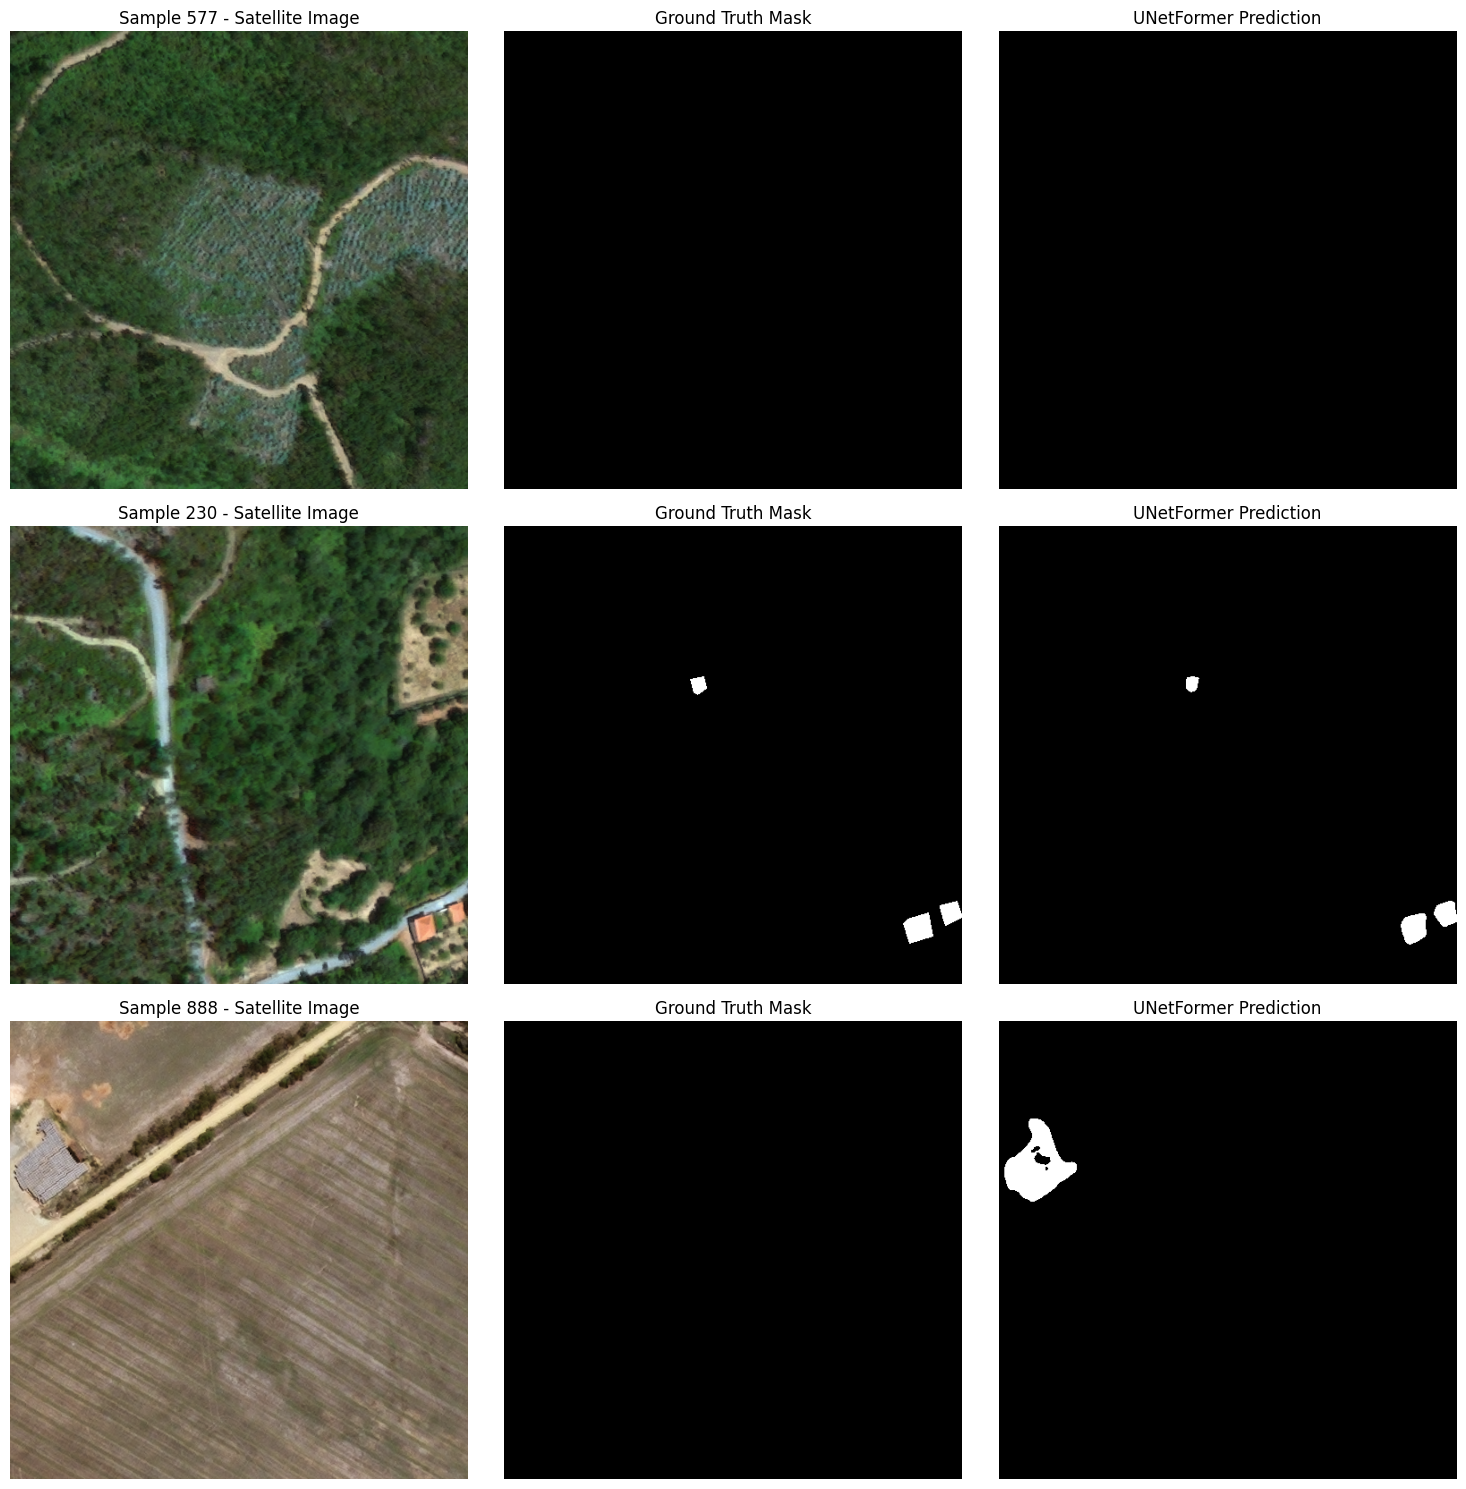

In [15]:

def visualize_predictions(model, dataset, device, num_samples=3):
    """
    Plots a grid comparing the original image, true building mask, and model predictions.
    """
    model.eval() # Put model in evaluation mode
    
    # Select random indices from the dataset
    indices = random.sample(range(len(dataset)), num_samples)
    
    # Set up the matplotlib plot grid
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    # Handle the case where num_samples is 1 to keep axes indexing consistent
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)
        
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # 1. Pull the image and mask from the dataset
            image_tensor, mask_tensor = dataset[idx]
            
            # 2. Generate the prediction
            # Add batch dimension (1, 3, 512, 512) and send to GPU
            input_tensor = image_tensor.unsqueeze(0).to(device)
            output = model(input_tensor)
            
            # Apply Sigmoid and threshold at 0.5 to convert logits to 0 or 1
            pred_mask = (torch.sigmoid(output) > 0.5).float()
            
            # 3. Convert PyTorch Tensors back to viewable NumPy arrays
            # Un-normalize the image back to standard RGB values for plotting
            inv_normalize = A.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225],
                max_pixel_value=1.0
            )
            
            # Permute dimensions from (Channels, Height, Width) to (Height, Width, Channels)
            img_to_show = image_tensor.permute(1, 2, 0).numpy()
            img_to_show = inv_normalize(image=img_to_show)['image']
            img_to_show = np.clip(img_to_show, 0, 1) # Ensure values fall strictly within [0, 1]
            
            true_mask_to_show = mask_tensor.squeeze().numpy()
            pred_mask_to_show = pred_mask.squeeze().cpu().numpy()
            
            # --- Plotting Row i ---
            # Column 1: Original Satellite Image
            axes[i, 0].imshow(img_to_show)
            axes[i, 0].set_title(f"Sample {idx} - Satellite Image")
            axes[i, 0].axis('off')
            
            # Column 2: True Ground Truth Boundaries
            axes[i, 1].imshow(true_mask_to_show, cmap='gray')
            axes[i, 1].set_title("Ground Truth Mask")
            axes[i, 1].axis('off')
            
            # Column 3: Model Predicted Boundaries
            axes[i, 2].imshow(pred_mask_to_show, cmap='gray')
            axes[i, 2].set_title("UNetFormer Prediction")
            axes[i, 2].axis('off')
            
    plt.tight_layout()
    plt.show()

# 🏃 Run the visualization using your validation dataset split
visualize_predictions(model, val_dataset, device, num_samples=3)